# Catenary Diagram Generator

This notebook generates a diagram showing the setup of the catenary problem: a uniform chain suspended between two fixed points.

The catenary curve is described by the equation:
$$y = a \cosh\left(\frac{x}{a}\right)$$

where $a$ is a parameter that depends on the tension and weight of the chain.


Diagram saved to ../img/catenary_diagram.png


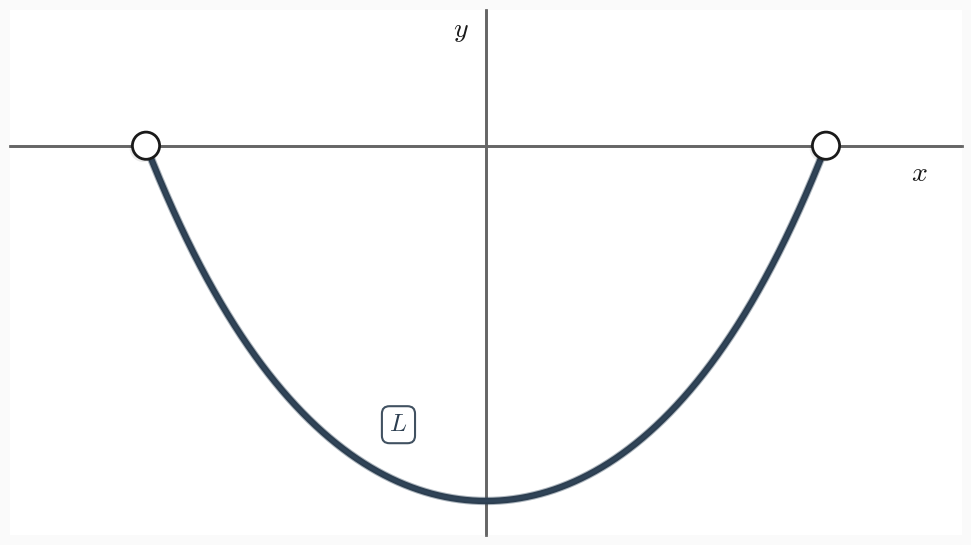

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.patheffects as path_effects

# Set up visually stunning style with nice font
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern', 'Latin Modern Roman', 'Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern for math
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

# Create figure with subtle gradient background effect
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#fafafa')

# Parameters: supports at x=-1 and x=1, both at y=0
x_left = -1.0
x_right = 1.0
y_support = 0.0

# Catenary parameter - chosen so the curve looks nice
a = 0.6
y0 = -a * np.cosh(1.0 / a)

# Generate x values with high resolution for smooth curve
x = np.linspace(x_left, x_right, 3000)

# Catenary equation: y = a * cosh(x/a) + y0
y = a * np.cosh(x / a) + y0

# Calculate chain length (arc length) for labeling
# L = integral of sqrt(1 + (dy/dx)^2) dx
dy_dx = np.sinh(x / a)
ds = np.sqrt(1 + dy_dx**2) * (x[1] - x[0])
chain_length = np.sum(ds)

# Plot the catenary curve with beautiful styling
# Use a gradient-like effect with multiple layers for depth
ax.plot(x, y, '#2c3e50', linewidth=4.5, zorder=3, solid_capstyle='round',
        path_effects=[path_effects.withStroke(linewidth=6, foreground='#34495e', alpha=0.4)])

# Add a subtle highlight on top of the curve
ax.plot(x, y, '#34495e', linewidth=2, zorder=4, alpha=0.6, solid_capstyle='round')

# Draw centered axes
ax.axhline(y=0, color='#333333', linestyle='-', linewidth=2, zorder=1, alpha=0.6)
ax.axvline(x=0, color='#333333', linestyle='-', linewidth=2, zorder=1, alpha=0.6)

# Add axis labels positioned to avoid overlap with axes
# Position x label to the right, y label above
ax.text(1.25, -0.05, '$x$', fontsize=20, ha='left', va='top', 
        color='#1a1a1a', weight='bold', zorder=5, fontfamily='serif')
ax.text(-0.05, 0.3, '$y$', fontsize=20, ha='right', va='bottom', 
        color='#1a1a1a', weight='bold', zorder=5, fontfamily='serif')

# Draw smaller support points
support_radius = 0.04  # Smaller radius
support_circle_left = Circle((x_left, y_support), support_radius, 
                             facecolor='white', edgecolor='#1a1a1a', 
                             linewidth=2, zorder=5)
support_circle_right = Circle((x_right, y_support), support_radius, 
                              facecolor='white', edgecolor='#1a1a1a', 
                              linewidth=2, zorder=5)
ax.add_patch(support_circle_left)
ax.add_patch(support_circle_right)

# Add subtle shadow circles for depth (smaller to match)
shadow_left = Circle((x_left - 0.008, y_support - 0.008), support_radius, 
                     facecolor='black', alpha=0.08, zorder=4)
shadow_right = Circle((x_right - 0.008, y_support - 0.008), support_radius, 
                      facecolor='black', alpha=0.08, zorder=4)
ax.add_patch(shadow_left)
ax.add_patch(shadow_right)

# Add "L" label along the chain curve
# Find a point along the curve that's nicely positioned (around 1/3 from left)
label_x_idx = len(x) // 3
label_x = x[label_x_idx]
label_y = y[label_x_idx]

# Calculate the tangent angle for proper label orientation
tangent_angle = np.arctan(np.sinh(label_x / a)) * 180 / np.pi

# Position label slightly offset from the curve
offset_distance = 0.15
normal_angle = tangent_angle + 90
normal_rad = np.radians(normal_angle)
label_x_pos = label_x + offset_distance * np.cos(normal_rad)
label_y_pos = label_y + offset_distance * np.sin(normal_rad)

# Add the "L" label with nice styling
ax.text(label_x_pos, label_y_pos, '$L$', fontsize=18, ha='center', va='center',
        color='#2c3e50', weight='bold', zorder=5, fontfamily='serif',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                  edgecolor='#2c3e50', linewidth=1.5, alpha=0.9))

# Set axis limits
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(y.min() - 0.1, 0.4)

# Style the axes - centered
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_color('#666666')
ax.spines['left'].set_color('#666666')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)

# Remove ticks but keep axis lines
ax.set_xticks([])
ax.set_yticks([])

# Remove labels
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')

# Remove grid
ax.grid(False)

# Set aspect ratio for better proportions
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()

# Save the figure with high quality
output_path = '../img/catenary_diagram.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', 
            edgecolor='none', pad_inches=0.15)
print(f"Diagram saved to {output_path}")

plt.show()


## Force Diagram

This diagram shows the forces acting on a segment of the chain, including the tensions and weight.


Force diagram saved to ../img/catenary_force_diagram.png


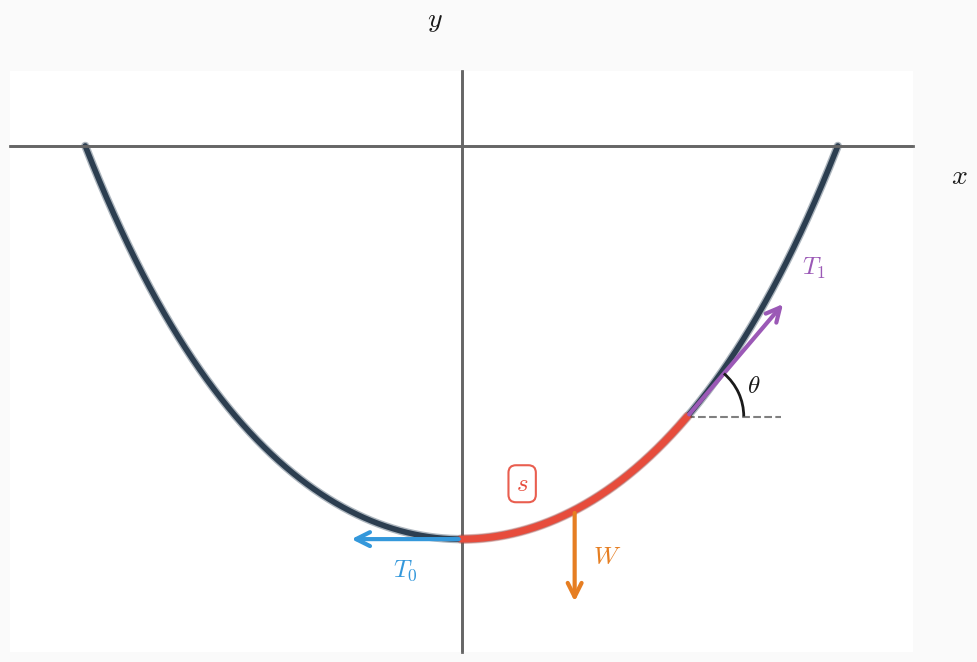

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Arc
from matplotlib.patches import Circle
import matplotlib.patheffects as path_effects

# Set up visually stunning style with nice font
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern', 'Latin Modern Roman', 'Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern for math
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 2

# Create figure for force diagram
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#fafafa')

# Parameters: same as main diagram
a = 0.6
y0 = -a * np.cosh(1.0 / a)

# Generate full chain (from -1 to 1)
x_full = np.linspace(-1.0, 1.0, 2000)
y_full = a * np.cosh(x_full / a) + y0

# Plot the full chain in original color
ax.plot(x_full, y_full, '#2c3e50', linewidth=4, zorder=2, solid_capstyle='round',
        path_effects=[path_effects.withStroke(linewidth=6, foreground='#34495e', alpha=0.4)])

# Define the segment: from bottom (x=0) to a point on the right side
x_bottom = 0.0
y_bottom = y0 + a # Bottom of chain

# Choose a point on the right side of the chain (between bottom and edge)
x_edge = 0.6  # Some point between 0 and 1
y_edge = a * np.cosh(x_edge / a) + y0

# Calculate the angle theta (angle T1 makes with horizontal)
dy_dx = np.sinh(x_edge / a)
theta_rad = np.arctan(dy_dx)
theta_deg = np.degrees(theta_rad)

# Generate points for the chain segment (colored differently)
x_segment = np.linspace(x_bottom, x_edge, 500)
y_segment = a * np.cosh(x_segment / a) + y0

# Plot the chain segment in a different color (on top of full chain)
ax.plot(x_segment, y_segment, '#e74c3c', linewidth=5, zorder=3, solid_capstyle='round',
        path_effects=[path_effects.withStroke(linewidth=7, foreground='#c0392b', alpha=0.3)])

# Calculate segment length s (arc length)
dx_seg = x_segment[1] - x_segment[0]
dy_dx_seg = np.sinh(x_segment / a)
ds_seg = np.sqrt(1 + dy_dx_seg**2) * dx_seg
s_length = np.sum(ds_seg)

# Draw centered axes
ax.axhline(y=0, color='#333333', linestyle='-', linewidth=2, zorder=1, alpha=0.6)
ax.axvline(x=0, color='#333333', linestyle='-', linewidth=2, zorder=1, alpha=0.6)

# Add axis labels
ax.text(1.3, -0.05, '$x$', fontsize=20, ha='left', va='top', 
        color='#1a1a1a', weight='bold', zorder=5, fontfamily='serif')
ax.text(-0.05, 0.3, '$y$', fontsize=20, ha='right', va='bottom', 
        color='#1a1a1a', weight='bold', zorder=5, fontfamily='serif')

# 1. Draw T0 arrow at bottom (along chain direction - horizontal to the right at bottom)
# At the bottom, the chain is horizontal (tangent is 0), so T0 points along the chain
T0_length = 0.3
# T0 points along the chain direction at the bottom (to the right, horizontal)
T0_arrow = FancyArrowPatch((x_bottom, y_bottom), (x_bottom - T0_length, y_bottom),
                           arrowstyle='->', mutation_scale=25, linewidth=3,
                           color='#3498db', zorder=4)
ax.add_patch(T0_arrow)
ax.text(x_bottom - T0_length/2, y_bottom - 0.05, '$T_0$', fontsize=18, 
        ha='center', va='top', color='#3498db', weight='bold', zorder=5, fontfamily='serif')

# 2. Draw T1 arrow at edge (parallel to chain, along the tangent)
T1_length = 0.4
# T1 direction is along the tangent
T1_dx = T1_length * np.cos(theta_rad)
T1_dy = T1_length * np.sin(theta_rad)
T1_arrow = FancyArrowPatch((x_edge, y_edge), (x_edge + T1_dx, y_edge + T1_dy),
                           arrowstyle='->', mutation_scale=25, linewidth=3,
                           color='#9b59b6', zorder=4)
ax.add_patch(T1_arrow)
# Label T1 offset from arrow
T1_label_x = x_edge + T1_dx * 1.3
T1_label_y = y_edge + T1_dy * 1.3
ax.text(T1_label_x, T1_label_y, '$T_1$', fontsize=18, 
        ha='center', va='center', color='#9b59b6', weight='bold', zorder=5, fontfamily='serif')

# 3. Draw dashed horizontal line from edge point to show angle theta
dash_length = 0.25
ax.plot([x_edge, x_edge + dash_length], [y_edge, y_edge], 'k--', 
        linewidth=1.5, alpha=0.5, zorder=2)

# 4. Draw angle arc and label theta
arc_radius = 0.15
arc = Arc((x_edge, y_edge), 2*arc_radius, 2*arc_radius, angle=0, 
          theta1=0, theta2=theta_deg, color='#1a1a1a', linewidth=2, zorder=4)
ax.add_patch(arc)
# Label theta
theta_label_x = x_edge + arc_radius * 1.3 * np.cos(theta_rad/2)
theta_label_y = y_edge + arc_radius * 1.3 * np.sin(theta_rad/2)
ax.text(theta_label_x, theta_label_y, r'$\theta$', fontsize=18, 
        ha='center', va='center', color='#1a1a1a', weight='bold', zorder=5, fontfamily='serif')

# 5. Draw W arrow (downward, in the middle of the segment)
mid_idx = len(x_segment) // 2
x_mid = x_segment[mid_idx]
y_mid = y_segment[mid_idx]
W_length = 0.25
W_arrow = FancyArrowPatch((x_mid, y_mid), (x_mid, y_mid - W_length),
                         arrowstyle='->', mutation_scale=25, linewidth=3,
                         color='#e67e22', zorder=4)
ax.add_patch(W_arrow)
ax.text(x_mid + 0.05, y_mid - W_length/2, '$W$', fontsize=18, 
        ha='left', va='center', color='#e67e22', weight='bold', zorder=5, fontfamily='serif')

# 6. Label segment length s
# Position label along the segment
s_label_idx = len(x_segment) // 3
x_s_label = x_segment[s_label_idx]
y_s_label = y_segment[s_label_idx]
# Offset perpendicular to the curve
tangent_angle_s = np.arctan(np.sinh(x_s_label / a))
normal_angle_s = tangent_angle_s + np.pi/2
offset_s = 0.12
x_s_pos = x_s_label + offset_s * np.cos(normal_angle_s)
y_s_pos = y_s_label + offset_s * np.sin(normal_angle_s)
ax.text(x_s_pos, y_s_pos, '$s$', fontsize=18, ha='center', va='center',
        color='#e74c3c', weight='bold', zorder=5, fontfamily='serif',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                  edgecolor='#e74c3c', linewidth=1.5, alpha=0.9))

# Set axis limits to show full chain
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(y_bottom - 0.3, 0.2)

# Style the axes - centered
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_color('#666666')
ax.spines['left'].set_color('#666666')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)

# Remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Remove labels
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')

# Remove grid
ax.grid(False)

# Set aspect ratio
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()

# Save the force diagram
output_path = '../img/catenary_force_diagram.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', 
            edgecolor='none', pad_inches=0.15)
print(f"Force diagram saved to {output_path}")

plt.show()
